# Graphiques — Pollution & Météo
Visualisations : séries temporelles, corrélations, top sites, carte.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

DATA_PATH = Path('../..') / 'data' / 'processed' / 'df_joined.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)
df['hour_utc'] = pd.to_datetime(df['hour_utc'], errors='coerce')
for c in ['valeur', 'indice_final', 'ff', 'pres', 't', 'u', 'lat', 'lon']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
print('Données chargées:', df.shape)

Données chargées: (47840, 67)


## 1. Série temporelle — indice_final moyen par heure

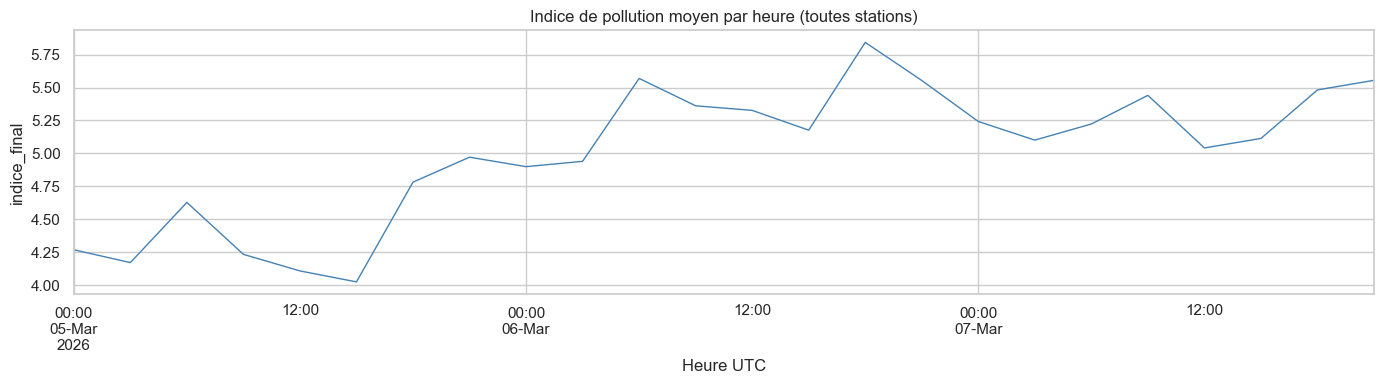

In [5]:
ts = df.groupby('hour_utc')['indice_final'].mean().dropna()

fig, ax = plt.subplots(figsize=(14, 4))
ts.plot(ax=ax, color='steelblue', linewidth=1)
ax.set_title('Indice de pollution moyen par heure (toutes stations)')
ax.set_xlabel('Heure UTC')
ax.set_ylabel('indice_final')
plt.tight_layout()
plt.show()

## 2. Série temporelle — valeur moyenne par polluant

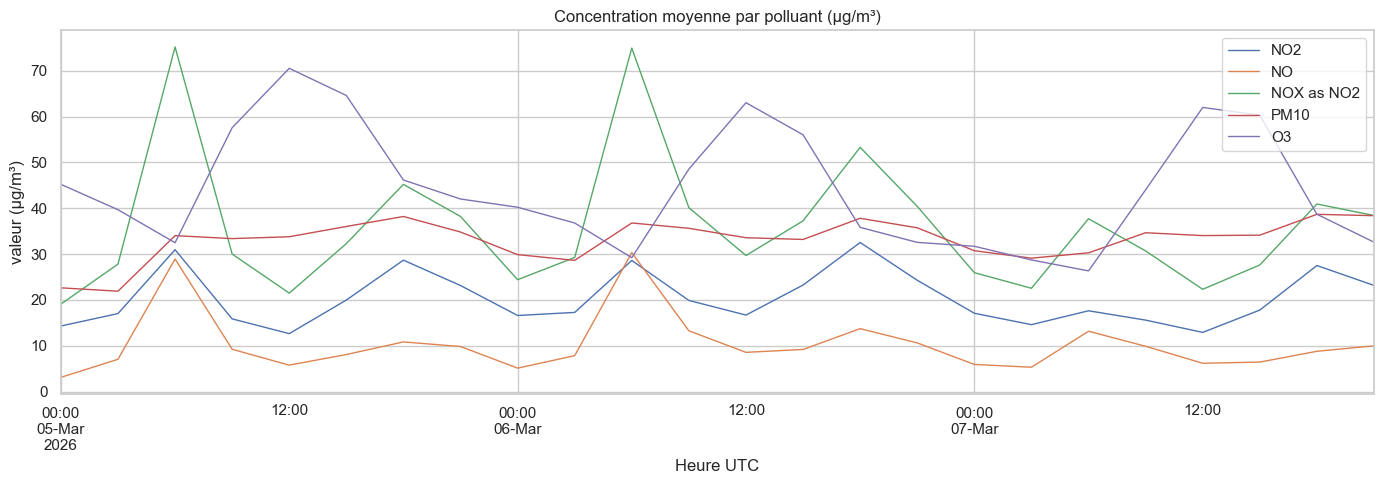

In [6]:
top_polluants = df['Polluant'].value_counts().head(5).index
fig, ax = plt.subplots(figsize=(14, 5))

for p in top_polluants:
    ts_p = df[df['Polluant'] == p].groupby('hour_utc')['valeur'].mean().dropna()
    if not ts_p.empty:
        ts_p.plot(ax=ax, label=p, linewidth=1)

ax.set_title('Concentration moyenne par polluant (µg/m³)')
ax.set_xlabel('Heure UTC')
ax.set_ylabel('valeur (µg/m³)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Top 15 sites les plus pollués (indice_final moyen)

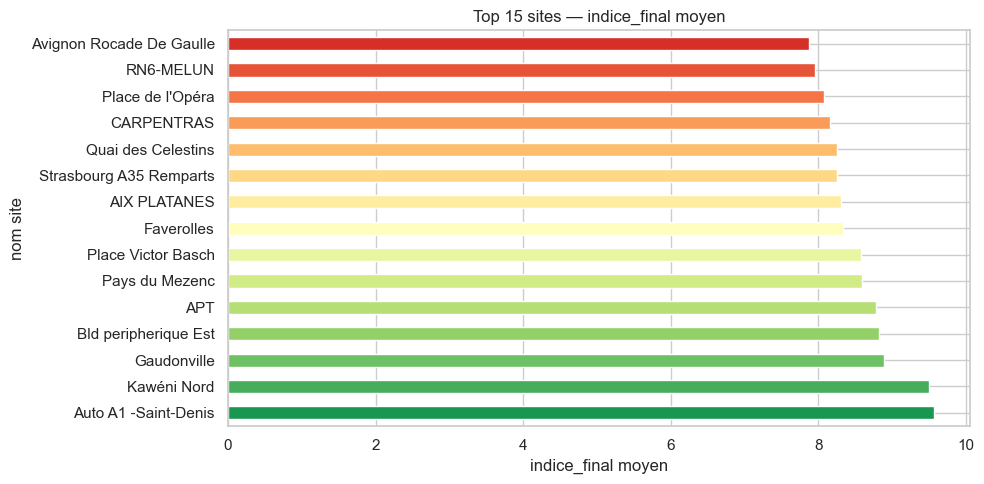

In [7]:
top_sites = (
    df.groupby('nom site')['indice_final']
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top_sites)))
top_sites.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 15 sites — indice_final moyen')
ax.set_xlabel('indice_final moyen')
plt.tight_layout()
plt.show()

## 4. Corrélation entre variables météo et indice_final

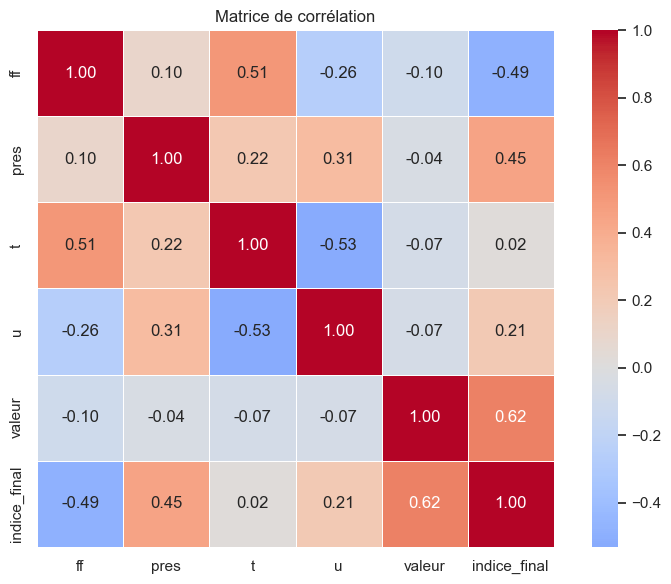

In [8]:
meteo_cols = ['ff', 'pres', 't', 'u', 'valeur', 'indice_final']
corr = df[meteo_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Matrice de corrélation')
plt.tight_layout()
plt.show()

## 5. Pollution vs Température & Vent

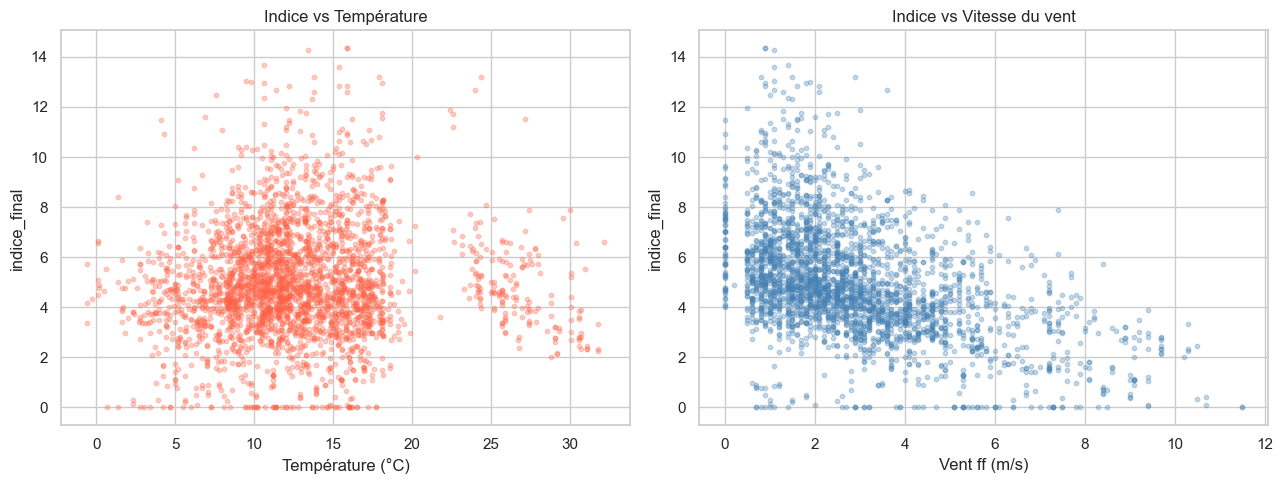

In [9]:
sample = df[['t', 'ff', 'valeur', 'indice_final']].dropna().sample(min(3000, len(df)), random_state=42)
# Température en °C (les données SYNOP sont en Kelvin)
sample['t_celsius'] = sample['t'] - 273.15

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(sample['t_celsius'], sample['indice_final'],
                alpha=0.3, s=10, c='tomato')
axes[0].set_title('Indice vs Température')
axes[0].set_xlabel('Température (°C)')
axes[0].set_ylabel('indice_final')

axes[1].scatter(sample['ff'], sample['indice_final'],
                alpha=0.3, s=10, c='steelblue')
axes[1].set_title('Indice vs Vitesse du vent')
axes[1].set_xlabel('Vent ff (m/s)')
axes[1].set_ylabel('indice_final')

plt.tight_layout()
plt.show()

## 6. Pollution par heure de la journée (profil journalier)

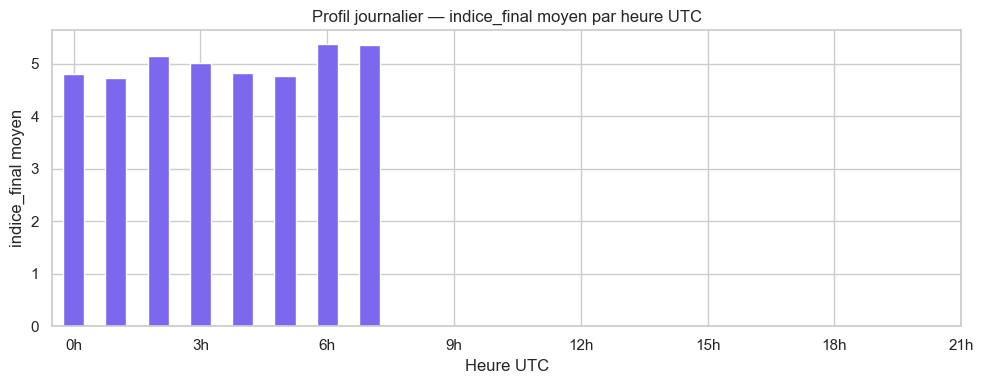

In [10]:
df['hour_of_day'] = df['hour_utc'].dt.hour
profile = df.groupby('hour_of_day')['indice_final'].mean().dropna()

fig, ax = plt.subplots(figsize=(10, 4))
profile.plot(kind='bar', ax=ax, color='mediumslateblue', edgecolor='white')
ax.set_title('Profil journalier — indice_final moyen par heure UTC')
ax.set_xlabel('Heure UTC')
ax.set_ylabel('indice_final moyen')
ax.set_xticks(range(0, 24, 3))
ax.set_xticklabels([f'{h}h' for h in range(0, 24, 3)], rotation=0)
plt.tight_layout()
plt.show()

## 7. Carte des stations (scatter géographique coloré par indice)

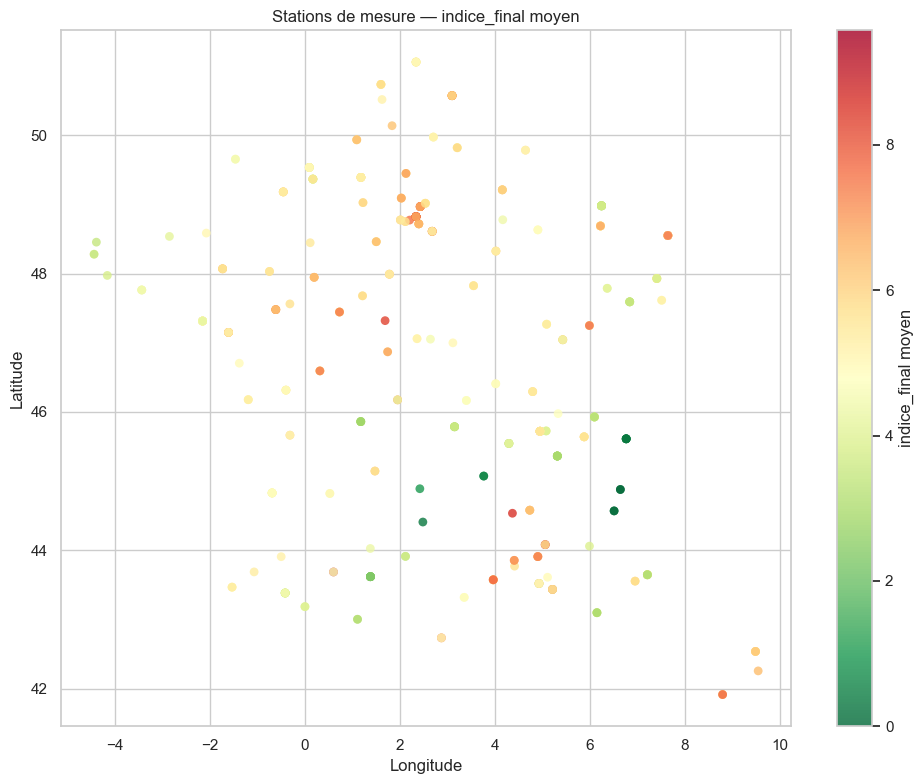

In [11]:
geo = (
    df.groupby(['nom site', 'lat', 'lon'])['indice_final']
    .mean()
    .reset_index()
    .dropna()
)
# Filtre France métropolitaine
geo_fr = geo[(geo['lat'].between(-10, 52)) & (geo['lon'].between(-6, 10))]

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    geo_fr['lon'], geo_fr['lat'],
    c=geo_fr['indice_final'], cmap='RdYlGn_r',
    s=40, alpha=0.8, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='indice_final moyen')
ax.set_title('Stations de mesure — indice_final moyen')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 8. Boxplot indice_final par polluant

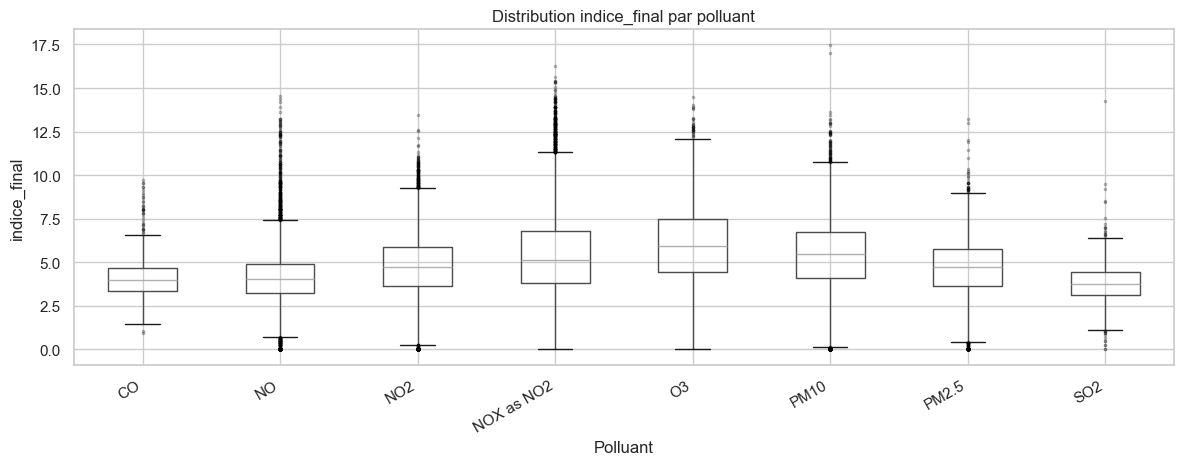

In [12]:
top_poll = df['Polluant'].value_counts().head(8).index
df_top = df[df['Polluant'].isin(top_poll)]

fig, ax = plt.subplots(figsize=(12, 5))
df_top.boxplot(column='indice_final', by='Polluant', ax=ax,
               flierprops=dict(marker='.', markersize=3, alpha=0.3))
ax.set_title('Distribution indice_final par polluant')
ax.set_xlabel('Polluant')
ax.set_ylabel('indice_final')
plt.suptitle('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()